In [ ]:
pip install pandas numpy matplotlib seaborn scipy

<h1>Import libraries </h1>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

<h2>Load Dataset</h2>

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Define the file path
file_path = "/content/drive/MyDrive/Colab Notebooks/e health/ehealth_data3.csv"

# Load the dataset with encoding handling
try:
    df = pd.read_csv(file_path, encoding='utf-8')  # Try UTF-8 encoding first
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='ISO-8859-1')  # Fallback encoding

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<h2>basic information about dataset</h2>

In [ ]:
df.head().style.set_table_attributes("style='display:block; max-height:300px; overflow-y:auto;'")


,id,name_of_the_institution,location,url,appointment_booking,find_doctors,online_report,telemedicine,online_consultation,online_payment,emergency_ambulance_service,health_record_card,home_service_booking,online_store,student_services,chatbot_assistant
0,1,Al-Rajhi Hospital Ltd.,Dhaka,https://alrajhihospital.com/,yes,yes,yes,no,no,no,no,no,no,no,no,no
1,2,Al-Baraka Diagnostic & Hospital Complex Ltd.,Dhaka,https://albarakadiagnostic.com/,yes,no,no,no,no,no,no,no,no,no,no,no
2,3,Al-Helal Specialized Hospital Limited,Dhaka,https://alhelalhospitalbd.com/appointment/,yes,no,no,no,no,no,no,no,no,no,no,no
3,4,Al-Manar Hospital Ltd.,Dhaka,https://almanarhospital.com/,yes,yes,yes,no,no,no,no,no,no,no,no,no
4,5,Aleya Eye Hospital,Dhaka,https://aleyaeyehospital.com/,yes,no,no,no,no,no,no,no,no,no,no,no


### Column Data Types

In [ ]:
# Display data types and example values
print("\nColumn Data Types and Sample Values:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}, Example: {df[col].iloc[0]}")




Column Data Types and Sample Values:
id: int64, Example: 1
name_of_the_institution: object, Example: Al-Rajhi Hospital Ltd.
location: object, Example: Dhaka
url: object, Example: https://alrajhihospital.com/
appointment_booking: object, Example: yes
find_doctors: object, Example: yes
online_report: object, Example: yes
telemedicine: object, Example: no
online_consultation: object, Example: no
online_payment: object, Example: no
emergency_ambulance_service: object, Example: no
health_record_card: object, Example: no
home_service_booking: object, Example: no
online_store: object, Example: no
student_services: object, Example: no
chatbot_assistant: object, Example: no


### frequency of each unique location

In [ ]:
# Count the frequency of each unique location and display as a table
location_distribution = df['location'].value_counts().reset_index()
location_distribution.columns = ['Location', 'Frequency']
print(location_distribution)
total_locations = df['location'].nunique()
print("Total Unique Locations:", total_locations)

     Location  Frequency
0       Dhaka         51
1  Chattogram         12
2  Mymensingh          7
3      Khulna          5
4    Rajshahi          5
5      Sylhet          5
6     Rangpur          1
7    Barishal          1
Total Unique Locations: 8


<h3>Frequency of E-Health Features:</h3>

In [ ]:
# Define the service feature columns (excluding ID, Name, Location, and URL)
service_columns = df.columns[4:]

# Calculate 'yes' counts and percentages
count_yes = df[service_columns].apply(lambda x: x.value_counts().get('yes', 0)).fillna(0)
total_hospitals = len(df)
percentage_yes = (count_yes / total_hospitals) * 100

# Create a result DataFrame
result_df = pd.DataFrame({
    'Feature': service_columns,
    'Count (Yes)': count_yes.astype(int),
    'Percentage (%)': percentage_yes.round(2)
}).sort_values(by="Count (Yes)", ascending=False)  # Sorted for better visualization

# Display the result
print("\nFrequency of E-Health Features:\n")
print(result_df.to_string(index=False))


Frequency of E-Health Features:

                    Feature  Count (Yes)  Percentage (%)
        appointment_booking           82           94.25
               find_doctors           50           57.47
              online_report           24           27.59
               telemedicine           12           13.79
        online_consultation            8            9.20
emergency_ambulance_service            6            6.90
               online_store            5            5.75
             online_payment            4            4.60
       home_service_booking            3            3.45
           student_services            3            3.45
          chatbot_assistant            3            3.45
         health_record_card            2            2.30


## Result and discussion

### Features across various institutions ( min , max, SD)

In [ ]:

# Feature columns
feature_columns = [
    'appointment_booking', 'find_doctors', 'online_report', 'telemedicine',
    'online_consultation', 'online_payment', 'emergency_ambulance_service',
    'health_record_card', 'home_service_booking', 'online_store',
    'student_services', 'chatbot_assistant'
]

# Check if all feature columns exist
missing_cols = [col for col in feature_columns if col not in df.columns]
if missing_cols:
    print(f"Warning: These columns are missing from the dataset: {missing_cols}")
else:
    # Create a copy of the dataframe to avoid modifying the original df
    df_copy = df.copy()

    # Convert "yes" to 1 and "no" to 0
    df_copy[feature_columns] = df_copy[feature_columns].applymap(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

    # Calculate feature count for each institution
    df_copy['feature_count'] = df_copy[feature_columns].sum(axis=1)

    # Get max, min, and standard deviation (rounded to 2 decimal places)
    max_features = df_copy['feature_count'].max()
    min_features = df_copy['feature_count'].min()
    std_dev_features = round(df_copy['feature_count'].std(), 2)

    # Find institution(s) with maximum and minimum features
    max_inst = df_copy[df_copy['feature_count'] == max_features][['name_of_the_institution', 'url']]
    min_inst = df_copy[df_copy['feature_count'] == min_features][['name_of_the_institution', 'url']]

    # Print results
    print(f"Maximum Number of Features: {max_features}")
    print(f"Minimum Number of Features: {min_features}")
    print(f"Standard Deviation of Features: {std_dev_features}\n")

    print("🔹 Institution(s) with MAXIMUM Features:")
    print(max_inst.to_string(index=False))

    print("\n🔹 Institution(s) with MINIMUM Features:")
    print(min_inst.to_string(index=False))


Maximum Number of Features: 6
Minimum Number of Features: 1
Standard Deviation of Features: 1.04

🔹 Institution(s) with MAXIMUM Features:
name_of_the_institution                            url
       AMZ Hospital LTD https://www.amzhospitalbd.com/

🔹 Institution(s) with MINIMUM Features:
                             name_of_the_institution                                                   url
        Al-Baraka Diagnostic & Hospital Complex Ltd.                       https://albarakadiagnostic.com/
               Al-Helal Specialized Hospital Limited            https://alhelalhospitalbd.com/appointment/
                                  Aleya Eye Hospital                         https://aleyaeyehospital.com/
                              Samela Memorial Clinic                             https://samelaclinic.com/
                                 Nova Medical Center                            https://novamedicalbd.com/
                         Bangladesh City Hospital BD                 

<ipython-input-15-c6f8824030bf>:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_copy[feature_columns] = df_copy[feature_columns].applymap(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)


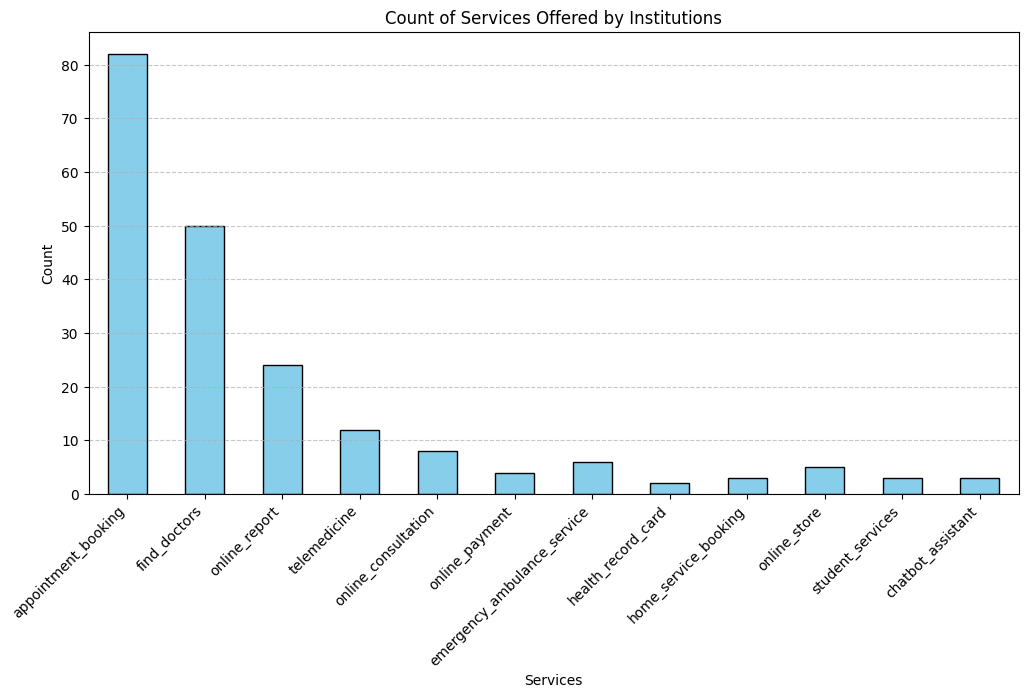


Correlation Matrix of Services:

                             appointment_booking  find_doctors  online_report  \
appointment_booking                     1.000000     -0.012630      -0.068584   
find_doctors                           -0.012630      1.000000       0.218836   
online_report                          -0.068584      0.218836       1.000000   
telemedicine                           -0.187669     -0.060449       0.051434   
online_consultation                     0.078580     -0.128550      -0.107413   
online_payment                          0.054209     -0.144186      -0.012703   
emergency_ambulance_service             0.067206     -0.041130       0.034997   
health_record_card                      0.037878     -0.023181      -0.094676   
home_service_booking                    0.046666      0.035150       0.024300   
online_store                            0.060976     -0.287053      -0.152410   
student_services                       -0.223996     -0.219687      -0.1166

In [ ]:
# Standardize column names (strip spaces & lowercase)
df.columns = df.columns.str.strip().str.lower()

# Count of services offered by each institution
service_counts = count_yes

# Visualization - Count of services offered
plt.figure(figsize=(12, 6))
service_counts.plot(kind='bar', color="skyblue", edgecolor="black")
plt.title('Count of Services Offered by Institutions')
plt.xlabel('Services')
plt.ylabel('Count')
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()







Correlation Matrix of Services:

                             appointment_booking  find_doctors  online_report  \
appointment_booking                     1.000000     -0.012630      -0.068584   
find_doctors                           -0.012630      1.000000       0.218836   
online_report                          -0.068584      0.218836       1.000000   
telemedicine                           -0.187669     -0.060449       0.051434   
online_consultation                     0.078580     -0.128550      -0.107413   
online_payment                          0.054209     -0.144186      -0.012703   
emergency_ambulance_service             0.067206     -0.041130       0.034997   
health_record_card                      0.037878     -0.023181      -0.094676   
home_service_booking                    0.046666      0.035150       0.024300   
online_store                            0.060976     -0.287053      -0.152410   
student_services                       -0.223996     -0.219687      -0.1166

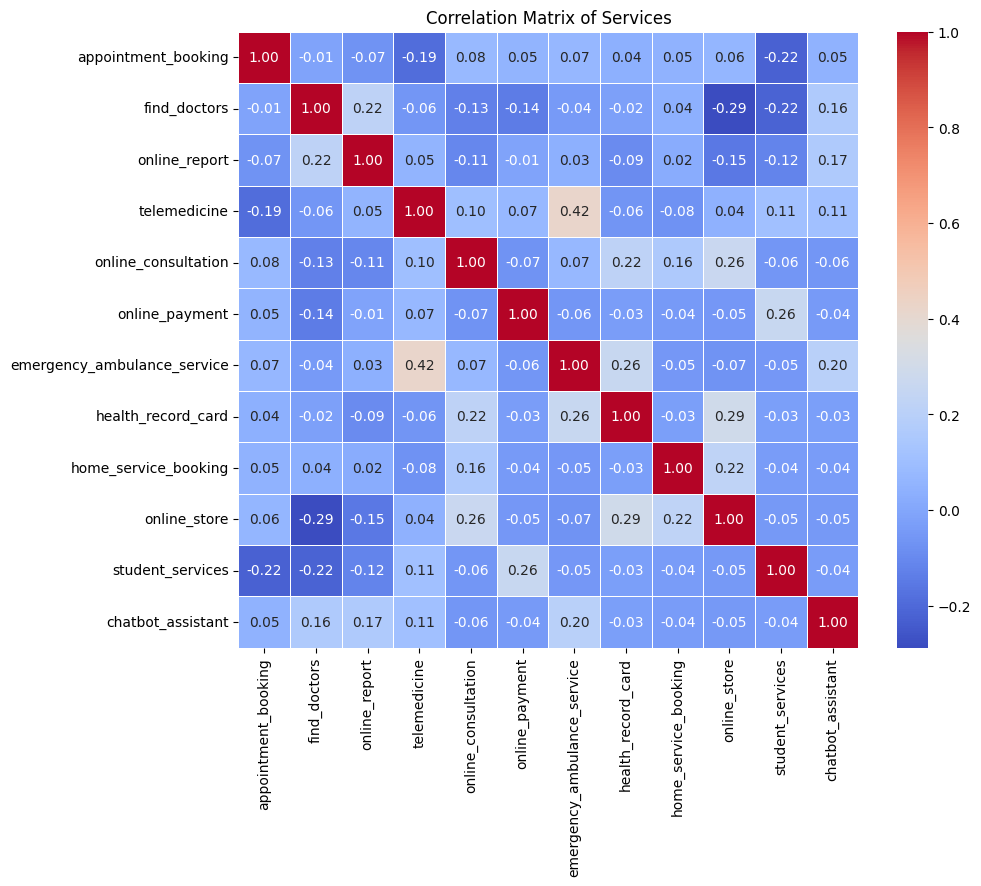

In [ ]:
# Correlation matrix for services (Convert 'yes'/'no' to 1/0)
df_services = df[service_columns].apply(lambda x: x.map({'yes': 1, 'no': 0}))
correlation_matrix = df_services.corr()

print("\nCorrelation Matrix of Services:\n")
print(correlation_matrix)

# Visualization - Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Services')
plt.show()